<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Cosmos001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


In [ ]:
alpha = 0.72  # HES expansion exponent
t0 = 4.35e17  # Age of universe in seconds


In [ ]:
def t_of_z(z):
    return t0 * (1 + z)**(-1 / alpha)

def H_HES(z):
    return alpha / t_of_z(z)

def d_L_HES(z):
    integrand = lambda z_prime: 1 / H_HES(z_prime)
    integral, _ = quad(integrand, 0, z)
    return (1 + z) * integral


In [ ]:
H0 = 70e3 / 3.086e22  # Hubble constant in 1/s
Omega_m = 0.3
Omega_L = 0.7

def H_LCDM(z):
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

def d_L_LCDM(z):
    integrand = lambda z_prime: 1 / H_LCDM(z_prime)
    integral, _ = quad(integrand, 0, z)
    return (1 + z) * integral


In [ ]:
def mu(d_L):
    return 5 * np.log10(d_L * 3.086e22) - 5  # Convert to parsecs


In [ ]:
z_vals = np.linspace(0.01, 2.0, 50)
mu_obs = mu(np.array([d_L_LCDM(z) for z in z_vals])) + np.random.normal(0, 0.2, len(z_vals))


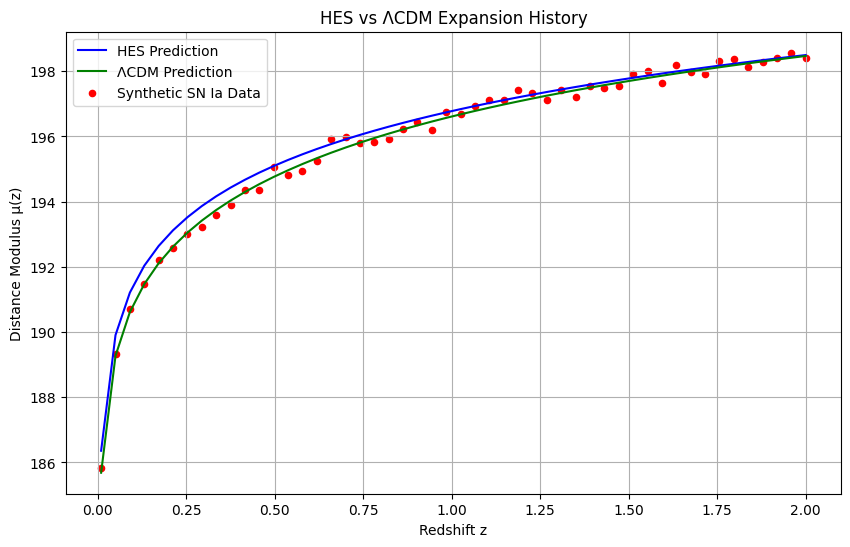

In [ ]:
mu_hes = mu(np.array([d_L_HES(z) for z in z_vals]))
mu_lcdm = mu(np.array([d_L_LCDM(z) for z in z_vals]))

plt.figure(figsize=(10, 6))
plt.plot(z_vals, mu_hes, label='HES Prediction', color='blue')
plt.plot(z_vals, mu_lcdm, label='ΛCDM Prediction', color='green')
plt.scatter(z_vals, mu_obs, label='Synthetic SN Ia Data', color='red', s=20)
plt.xlabel('Redshift z')
plt.ylabel('Distance Modulus μ(z)')
plt.legend()
plt.title('HES vs ΛCDM Expansion History')
plt.grid(True)
plt.show()
